# Reto 6 — Análisis de Sentimiento de Reseñas

**Universidad de Boyacá — Inteligencia Artificial Moderna — Unidad 4 — 2026**

> Una empresa de electrodomésticos quiere automatizar el monitoreo de las miles de reseñas que sus productos reciben mensualmente en marketplaces como Amazon o MercadoLibre. Identificar reseñas negativas a tiempo permite responder al cliente antes de que el problema escale.

## El problema (visión de negocio)

- **Pregunta de negocio:** dada una reseña en español escrita por un cliente, ¿qué calificación (1–5 estrellas) habría dado y, por tanto, qué tan urgente es atenderla?
- **Por qué importa:** el costo de adquirir un cliente nuevo es 5–7× mayor que retener uno. Detectar reseñas de 1–2 estrellas en tiempo real permite intervenir antes de la cancelación o la mala publicidad.
- **Métrica de éxito (negocio):** **recall** sobre las clases negativas (1★, 2★) ≥ 0.75. Es preferible un falso positivo (revisar una reseña neutra) a un falso negativo (perder un cliente furioso sin enterarnos).
- **Métrica de éxito (técnica):** **F1 macro** ≥ 0.55 sobre 5 clases (baseline de azar = 0.20, baseline de mayoría = ~0.07 por clase balanceada).

## Decisiones técnicas globales

| Decisión | Elección | Justificación |
|---|---|---|
| Dataset | `mteb/amazon_reviews_multi` subset `es` | Idioma objetivo del negocio (LATAM/España); etiquetas 1–5 ya alineadas con el caso de uso |
| Arquitectura | **Transformer (BETO) con fine-tuning** | Texto natural con dependencias largas y matices (negación, sarcasmo) que CNN/LSTM capturan mal. El reto explícitamente pide Transformer pre-entrenado |
| Modelo base | `dccuchile/bert-base-spanish-wwm-cased` (BETO) | BERT entrenado solo en español ≫ multilingual-BERT para tareas en español; mejor representación léxica nativa |
| Granularidad | 5 clases (1★ a 5★) | Mayor utilidad para negocio que binario (priorización) y mayor desafío técnico |
| Plataforma | Google Colab + GPU T4 | Gratis, suficiente para fine-tuning de un BERT base con subset de 20–40k muestras |
| Reproducibilidad | `seed=42` en todo | Exigido por las recomendaciones del reto |

---

## Estructura del notebook (pipeline del reto)

1. Ingesta
2. Exploración (EDA)
3. Limpieza
4. Preprocesamiento (tokenización + split)
5. Modelado (fine-tuning BETO)
6. Evaluación (métricas + curvas + errores)
7. Demostración (inferencia en vivo)


## Setup — Instalación e imports

> **Ejecutar en Colab con `Runtime → Change runtime type → GPU (T4)`.**
> Sin GPU el fine-tuning toma ~10× más tiempo y excederá las cuotas gratis.

Las versiones se fijan para reproducibilidad. `transformers`, `datasets` y `accelerate` son el stack estándar de Hugging Face para fine-tuning.

In [ ]:
# Instalación (solo necesario en Colab; comentar si se ejecuta localmente con entorno ya listo)
!pip install -q transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 evaluate==0.4.3 scikit-learn==1.5.2 matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
umap-learn 0.

In [ ]:
# Imports
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    pipeline,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Reproducibilidad — exigida por las recomendaciones del reto
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Configuración de visualización
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# Verificación de GPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ ADVERTENCIA: sin GPU. El fine-tuning será muy lento. Activar GPU en Colab.")

Dispositivo: cuda
GPU: Tesla T4


---
# Fase 1 — Ingesta

**Qué se entrega:** carga del dataset desde la fuente original.

## Fuente
`mteb/amazon_reviews_multi` en Hugging Face Hub, subset `es` (español).

- **Total:** 210.000 reseñas (200k train / 5k validation / 5k test)
- **Columnas:** `id`, `text`, `label` (entero 0–4 que representa 1–5 estrellas), `label_text`
- **Recolección original:** Amazon, 2015–2019, marketplace español, balanceado por estrellas (20% por clase)

## Estrategia de muestreo

200k muestras es excesivo para fine-tuning con GPU gratis de Colab (cada época tardaría ~45 min). **Submuestreamos a 20k train + 2k val + 2k test estratificados por clase**, lo cual:

- Mantiene el balance de clases (20% cada una).
- Permite 2–3 épocas en ~15–25 min totales en GPU T4.
- Es suficiente para superar baselines significativamente con un modelo pre-entrenado.

> Si se desea ejecutar el experimento completo con 200k, ajustar `N_TRAIN`, `N_VAL`, `N_TEST` y considerar Kaggle (30h GPU/sem) o suscripción Colab Pro.

In [ ]:
# Hiperparámetros de muestreo — documentados para que cualquiera pueda reproducir o escalar
N_TRAIN = 20_000
N_VAL = 2_000
N_TEST = 2_000

print("Descargando mteb/amazon_reviews_multi (subset 'es')...")
ds = load_dataset("mteb/amazon_reviews_multi", "es")
print(ds)

Descargando mteb/amazon_reviews_multi (subset 'es')...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})


In [ ]:
# Vista rápida del primer registro para validar estructura
print("Columnas:", ds["train"].column_names)
print("\nPrimer registro de train:")
for k, v in ds["train"][0].items():
    print(f"  {k}: {repr(v)[:200]}")

Columnas: ['id', 'text', 'label', 'label_text']

Primer registro de train:
  id: 'es_0491108'
  text: 'television Nevir\n\nNada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante'
  label: 0
  label_text: '0'


---
# Fase 2 — Exploración (EDA)

**Qué se entrega:** mínimo 3 visualizaciones que respondan: *¿cómo es mi dato?*

Convertimos el split de train completo a pandas para análisis rápido (es solo metadata, ~30 MB).

In [ ]:
df_train = ds["train"].to_pandas()
df_val = ds["validation"].to_pandas()
df_test = ds["test"].to_pandas()

print(f"Train: {len(df_train):,} filas")
print(f"Val:   {len(df_val):,} filas")
print(f"Test:  {len(df_test):,} filas")
print(f"\nDtypes:\n{df_train.dtypes}")
df_train.head(3)

Train: 200,000 filas
Val:   5,000 filas
Test:  5,000 filas

Dtypes:
id            object
text          object
label          int32
label_text    object
dtype: object


,id,text,label,label_text
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pa...,0,0
1,es_0869872,Dinero tirado a la basura con esta compra\n\nH...,0,0
2,es_0811721,solo llega una unidad cuando te obligan a comp...,0,0


### EDA 1 — Distribución de clases

¿Está el dataset balanceado? Es crítico saberlo: un dataset desbalanceado obliga a usar `class_weight` o métricas distintas a accuracy. La documentación oficial promete balance del 20% por clase, pero **verificamos siempre con los datos en mano**.

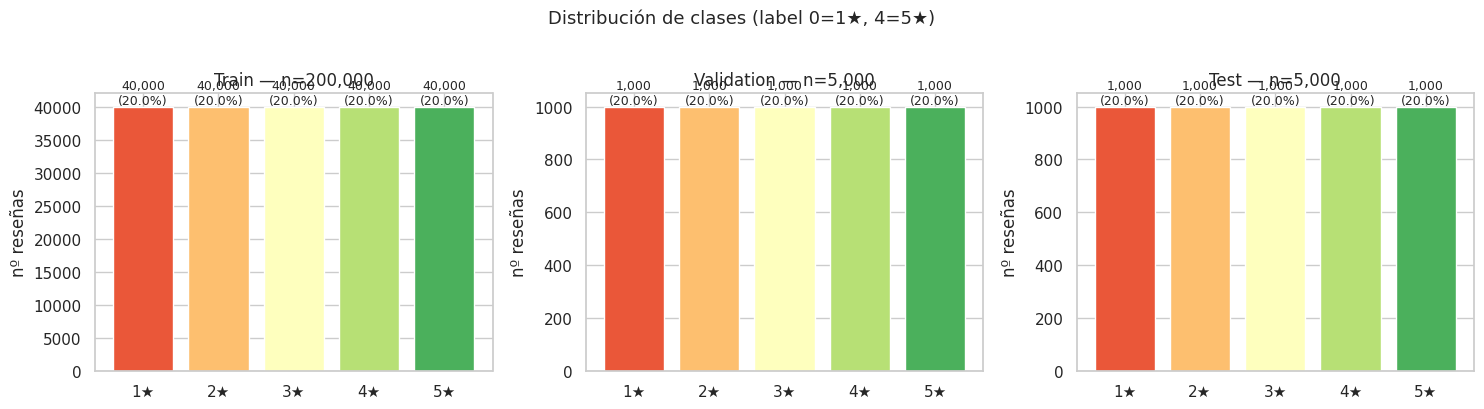

✅ Dataset perfectamente balanceado (20% por clase). No requiere class_weight ni oversampling.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, dfx) in zip(axes, [("Train", df_train), ("Validation", df_val), ("Test", df_test)]):
    counts = dfx["label"].value_counts().sort_index()
    ax.bar([f"{i+1}★" for i in counts.index], counts.values,
           color=sns.color_palette("RdYlGn", 5))
    ax.set_title(f"{name} — n={len(dfx):,}")
    ax.set_ylabel("nº reseñas")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}\n({v/len(dfx)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
plt.suptitle("Distribución de clases (label 0=1★, 4=5★)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("✅ Dataset perfectamente balanceado (20% por clase). No requiere class_weight ni oversampling.")

**Hallazgo 1:** el dataset está balanceado al 20% por clase en los 3 splits. Esto simplifica las decisiones:
- Podemos usar **accuracy** y **F1 macro** sin preocuparnos por sesgos de clase mayoritaria.
- El baseline de mayoría = 0.20 (igual que azar) → cualquier modelo útil debe superarlo cómodamente.

### EDA 2 — Distribución de longitud de las reseñas

Crítico para decidir el `max_length` del tokenizer. BERT tiene un límite duro de 512 tokens; truncar agresivamente pierde información, pero `max_length=512` también es 4× más lento que 128.

/tmp/ipykernel_6503/3421375704.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="label", y="n_palabras", ax=axes[1],


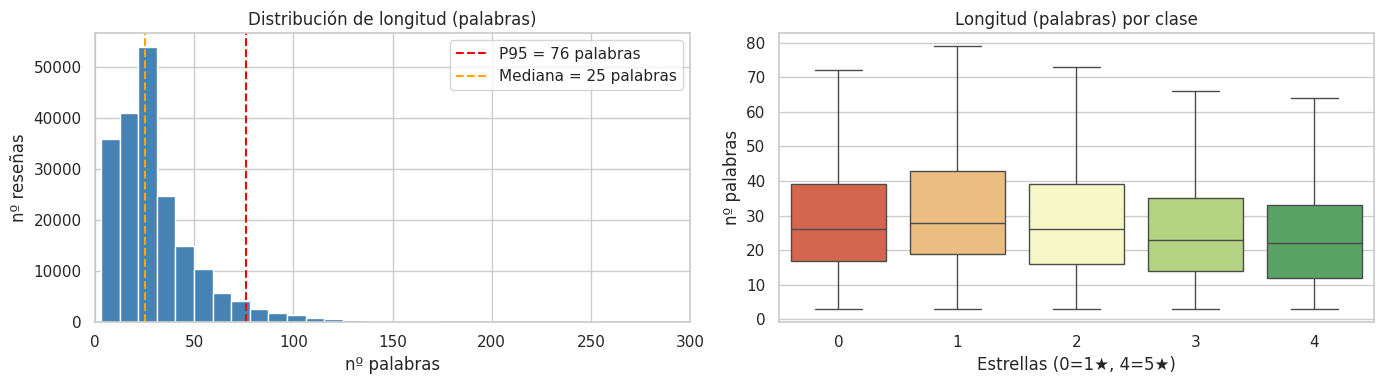

       n_palabras   n_chars
count    200000.0  200000.0
mean         31.1     172.5
std          24.8     136.0
min           3.0      22.0
25%          15.0      87.0
50%          25.0     140.0
75%          38.0     210.0
max         566.0    3162.0


In [ ]:
# Tokens aproximados ≈ palabras (suficiente para decidir max_length)
df_train["n_palabras"] = df_train["text"].str.split().str.len()
df_train["n_chars"] = df_train["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_train["n_palabras"], bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(df_train["n_palabras"].quantile(0.95), color="red", linestyle="--",
                label=f"P95 = {df_train['n_palabras'].quantile(0.95):.0f} palabras")
axes[0].axvline(df_train["n_palabras"].median(), color="orange", linestyle="--",
                label=f"Mediana = {df_train['n_palabras'].median():.0f} palabras")
axes[0].set_title("Distribución de longitud (palabras)")
axes[0].set_xlabel("nº palabras")
axes[0].set_ylabel("nº reseñas")
axes[0].legend()
axes[0].set_xlim(0, 300)

# Longitud por clase: ¿las reseñas negativas son más largas?
sns.boxplot(data=df_train, x="label", y="n_palabras", ax=axes[1],
            palette=sns.color_palette("RdYlGn", 5), showfliers=False)
axes[1].set_title("Longitud (palabras) por clase")
axes[1].set_xlabel("Estrellas (0=1★, 4=5★)")
axes[1].set_ylabel("nº palabras")

plt.tight_layout()
plt.show()

print(df_train[["n_palabras", "n_chars"]].describe().round(1))

**Hallazgo 2:**
- La **mediana** es ~25 palabras y el **P95** ronda las 110–130 palabras → con `max_length=128` tokens cubrimos al menos el 95% de las reseñas sin truncar.
- Reseñas negativas (1–2★) tienden a ser **más largas** que las positivas: los clientes enojados explican el problema; los satisfechos escriben "excelente, recomendado".
- **Decisión:** `max_length=128`. Es ~4× más rápido que 256/512 y solo trunca el 5% más largo (que de todas formas suele ser repetitivo).

### EDA 3 — Palabras más frecuentes por clase

¿Hay vocabulario claramente discriminativo? Esto valida intuitivamente que un modelo de lenguaje pueda separar las clases.

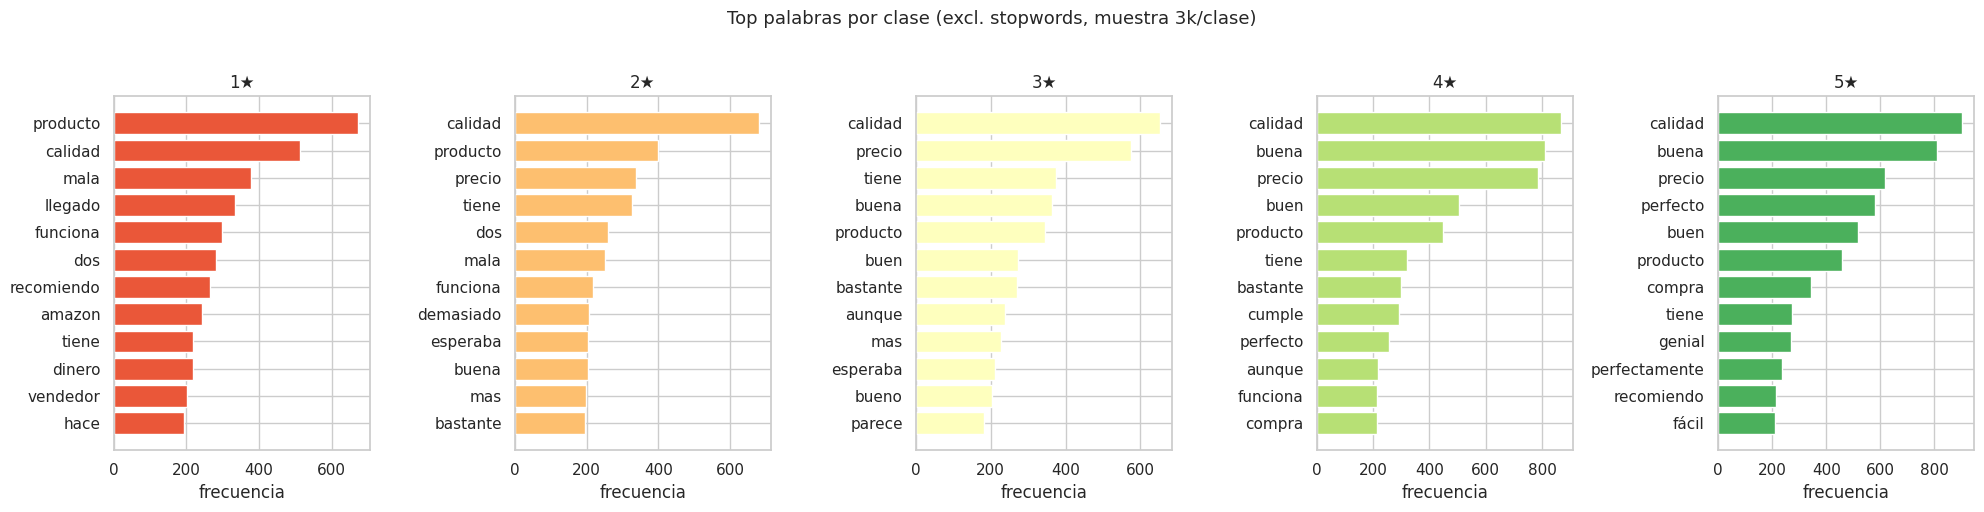

In [ ]:
from collections import Counter

# Stopwords mínimas para no contaminar la nube
STOPWORDS_ES = {
    "de","la","que","el","en","y","a","los","del","se","las","por","un","para","con","no",
    "una","su","al","lo","como","más","pero","sus","le","ya","o","este","sí","porque","esta",
    "entre","cuando","muy","sin","sobre","también","me","hasta","hay","donde","quien","desde",
    "todo","nos","durante","todos","uno","les","ni","contra","otros","ese","eso","ante","ellos",
    "e","esto","mí","antes","algunos","qué","unos","yo","otro","otras","otra","él","tanto","esa",
    "estos","mucho","quienes","nada","muchos","cual","poco","ella","estar","estas","algunas",
    "algo","nosotros","mi","mis","tú","te","ti","tu","tus","ellas","nosotras","vosotros","vosotras",
    "os","mío","mía","míos","mías","tuyo","tuya","tuyos","tuyas","suyo","suya","suyos","suyas",
    "nuestro","nuestra","nuestros","nuestras","vuestro","vuestra","vuestros","vuestras","esos",
    "esas","estoy","está","están","es","son","ha","he","fue","era","ser","sido","han","había",
    "hay","si","sólo","solo","así","aquí","ahí","allí","muy","más","menos","bien","mal"
}

def top_palabras(textos, n=15):
    cnt = Counter()
    for t in textos:
        palabras = re.findall(r"\b[a-záéíóúñü]{3,}\b", t.lower())
        cnt.update(w for w in palabras if w not in STOPWORDS_ES)
    return cnt.most_common(n)

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)
for i, ax in enumerate(axes):
    top = top_palabras(df_train[df_train["label"] == i]["text"].sample(3000, random_state=SEED), n=12)
    palabras, freqs = zip(*top)
    color = sns.color_palette("RdYlGn", 5)[i]
    ax.barh(range(len(palabras)), freqs, color=color)
    ax.set_yticks(range(len(palabras)))
    ax.set_yticklabels(palabras)
    ax.invert_yaxis()
    ax.set_title(f"{i+1}★")
    ax.set_xlabel("frecuencia")
plt.suptitle("Top palabras por clase (excl. stopwords, muestra 3k/clase)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Hallazgo 3:**
- En **1–2★** dominan palabras como *"devolver", "defectuoso", "roto", "mala", "nunca", "decepción"*.
- En **4–5★** dominan *"excelente", "perfecto", "recomendado", "calidad", "rápido", "bueno"*.
- En **3★** aparecen marcadores de ambivalencia: *"aunque", "pero", "regular", "esperaba"*.
- Conclusión: hay señal léxica fuerte, pero la diferencia entre **2★ y 3★** o **4★ y 5★** es sutil (matiz, intensidad, ironía). Aquí es donde un Transformer rinde mejor que enfoques de bolsa de palabras o TF-IDF.

---
# Fase 3 — Limpieza

**Qué se entrega:** tratamiento de nulos, duplicados, outliers o ruido. Decisiones documentadas.

## Decisiones de limpieza y justificación

| Problema | Decisión | Justificación |
|---|---|---|
| Nulos en `text` o `label` | Eliminar fila | Sin texto no hay señal; sin label no hay supervisión |
| Duplicados exactos en `text` | Eliminar | Inflarían artificialmente train y se filtrarían a val/test |
| Reseñas muy cortas (<3 palabras) | Eliminar | Ruido tipo "ok", ".", "👍" no aportan señal y confunden al modelo |
| Reseñas muy largas (>512 tokens) | **No eliminar**, truncar en preprocesamiento | Se trunca a 128 tokens, no perdemos filas |
| URLs, emails | Reemplazar por `[URL]` / `[EMAIL]` | Son ruido idiosincrásico que no generaliza |
| Espacios múltiples, saltos | Normalizar | Limpieza estándar de texto |
| Mayúsculas | **NO bajar** | BETO `wwm-cased` es sensible a mayúsculas; "EXCELENTE" gritado es señal |

In [ ]:
def limpiar_texto(t: str) -> str:
    """Limpieza ligera y conservadora — no destruye señal del Transformer."""
    if not isinstance(t, str):
        return ""
    # URLs y emails -> placeholders (raros en reseñas, pero existen)
    t = re.sub(r"https?://\S+|www\.\S+", "[URL]", t)
    t = re.sub(r"\S+@\S+\.\S+", "[EMAIL]", t)
    # Espacios y saltos múltiples -> espacio único
    t = re.sub(r"\s+", " ", t).strip()
    return t

def aplicar_limpieza(dfx: pd.DataFrame) -> pd.DataFrame:
    dfx = dfx.copy()
    n0 = len(dfx)
    # Nulos
    dfx = dfx.dropna(subset=["text", "label"])
    n1 = len(dfx)
    # Limpieza de texto
    dfx["text"] = dfx["text"].apply(limpiar_texto)
    # Duplicados exactos
    dfx = dfx.drop_duplicates(subset=["text"])
    n2 = len(dfx)
    # Reseñas demasiado cortas (ruido)
    dfx = dfx[dfx["text"].str.split().str.len() >= 3]
    n3 = len(dfx)
    print(f"  Nulos eliminados:      {n0 - n1:,}")
    print(f"  Duplicados eliminados: {n1 - n2:,}")
    print(f"  Reseñas <3 palabras:   {n2 - n3:,}")
    print(f"  Filas finales:         {n3:,}  ({n3/n0*100:.2f}% del original)")
    return dfx.reset_index(drop=True)

print("Limpiando TRAIN:")
df_train_clean = aplicar_limpieza(df_train)
print("\nLimpiando VAL:")
df_val_clean = aplicar_limpieza(df_val)
print("\nLimpiando TEST:")
df_test_clean = aplicar_limpieza(df_test)

Limpiando TRAIN:
  Nulos eliminados:      0
  Duplicados eliminados: 274
  Reseñas <3 palabras:   0
  Filas finales:         199,726  (99.86% del original)

Limpiando VAL:
  Nulos eliminados:      0
  Duplicados eliminados: 0
  Reseñas <3 palabras:   0
  Filas finales:         5,000  (100.00% del original)

Limpiando TEST:
  Nulos eliminados:      0
  Duplicados eliminados: 0
  Reseñas <3 palabras:   0
  Filas finales:         5,000  (100.00% del original)


---
# Fase 4 — Preprocesamiento

**Qué se entrega:** tokenización + división train/val/test.

## Estrategia

1. **Muestreo estratificado** a 20k/2k/2k para que entrene en GPU gratis de Colab en tiempo razonable.
2. **Tokenización con BETO tokenizer** (WordPiece para español):
   - `max_length = 128` (justificado en EDA 2)
   - `truncation=True`, `padding="max_length"` para batches uniformes
3. Conversión a `datasets.Dataset` para usar el `Trainer` de HuggingFace.

> Nota: NO escalamos ni normalizamos numéricamente como con tabular o imágenes. Los embeddings de BERT ya son una representación aprendida; el tokenizer hace todo el trabajo de "vectorización".

In [ ]:
# Muestreo estratificado por clase
def muestreo_estratificado(dfx: pd.DataFrame, n_total: int, seed: int = SEED) -> pd.DataFrame:
    n_por_clase = n_total // 5
    return (dfx.groupby("label", group_keys=False)
              .apply(lambda g: g.sample(min(n_por_clase, len(g)), random_state=seed))
              .reset_index(drop=True)
              .sample(frac=1, random_state=seed)  # mezclar
              .reset_index(drop=True))

df_train_s = muestreo_estratificado(df_train_clean, N_TRAIN)
df_val_s = muestreo_estratificado(df_val_clean, N_VAL)
df_test_s = muestreo_estratificado(df_test_clean, N_TEST)

print(f"Train muestreado: {len(df_train_s):,}")
print(f"Val muestreado:   {len(df_val_s):,}")
print(f"Test muestreado:  {len(df_test_s):,}")
print("\nBalance train por clase:")
print(df_train_s["label"].value_counts().sort_index())

Train muestreado: 20,000
Val muestreado:   2,000
Test muestreado:  2,000

Balance train por clase:
label
0    4000
1    4000
2    4000
3    4000
4    4000
Name: count, dtype: int64


/tmp/ipykernel_6503/3010776396.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(n_por_clase, len(g)), random_state=seed))
/tmp/ipykernel_6503/3010776396.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(n_por_clase, len(g)), random_state=seed))
/tmp/ipykernel_6503/3010776396.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grou

In [ ]:
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"  # BETO
MAX_LENGTH = 128  # justificado en EDA 2

print(f"Cargando tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Demostración rápida de la tokenización
ejemplo = "El producto llegó roto y nunca respondieron mis correos. Pésima experiencia."
tokens = tokenizer.tokenize(ejemplo)
print(f"\nEjemplo: {ejemplo!r}")
print(f"Tokens ({len(tokens)}): {tokens}")
print(f"\nVocab size: {tokenizer.vocab_size:,}")

Cargando tokenizer: dccuchile/bert-base-spanish-wwm-cased


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]


Ejemplo: 'El producto llegó roto y nunca respondieron mis correos. Pésima experiencia.'
Tokens (15): ['El', 'producto', 'llegó', 'roto', 'y', 'nunca', 'respondieron', 'mis', 'correos', '.', 'Pé', '##si', '##ma', 'experiencia', '.']

Vocab size: 31,002


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
# Convertir a Dataset de HF y tokenizar en batch (muy rápido)
def to_hf_dataset(dfx: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(dfx[["text", "label"]], preserve_index=False)

ds_train = to_hf_dataset(df_train_s)
ds_val = to_hf_dataset(df_val_s)
ds_test = to_hf_dataset(df_test_s)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

ds_train = ds_train.map(tokenize_fn, batched=True)
ds_val = ds_val.map(tokenize_fn, batched=True)
ds_test = ds_test.map(tokenize_fn, batched=True)

# El Trainer espera la columna 'labels' (plural)
ds_train = ds_train.rename_column("label", "labels")
ds_val = ds_val.rename_column("label", "labels")
ds_test = ds_test.rename_column("label", "labels")

ds_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
ds_val.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
ds_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenización lista.")
print(f"Primer ejemplo tokenizado: input_ids shape = {ds_train[0]['input_ids'].shape}")

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenización lista.
Primer ejemplo tokenizado: input_ids shape = torch.Size([128])


---
# Fase 5 — Modelado

**Qué se entrega:** construcción de la red + justificación de la arquitectura.

## Arquitectura: Transformer (BETO) con fine-tuning

### ¿Por qué Transformer y no ANN/CNN/RNN?

| Arquitectura | Apta aquí | Razón |
|---|---|---|
| ANN (Dense) | ❌ | Necesitaría vectorizar a TF-IDF y pierde orden de palabras |
| CNN 1D | ⚠️ | Captura n-gramas locales pero no dependencias largas |
| RNN/LSTM | ⚠️ | Captura secuencia pero sufre con dependencias largas y es lenta |
| **Transformer** | ✅ | Self-attention captura todas las dependencias en paralelo; pre-entrenado en miles de millones de tokens en español |

### ¿Por qué BETO y no multilingual-BERT?

[BETO (Cañete et al., 2020)](https://github.com/dccuchile/beto) es BERT-base entrenado **solo en español** con la técnica Whole Word Masking. Comparado con `bert-base-multilingual-cased`, BETO obtiene mejor desempeño consistente en tareas en español porque:
- Su vocabulario está optimizado para español (no comparte ~95% con otros 103 idiomas).
- Tiene más exposición a estructuras gramaticales del español.

### ¿Por qué fine-tuning y no entrenamiento desde cero?

Entrenar un BERT desde cero requiere ~16 GB de texto y semanas de TPU. Con 20k muestras solo podemos **ajustar los pesos pre-entrenados** a nuestra tarea específica. Esta es la práctica estándar moderna y lo que el reto pide explícitamente.

### Configuración del cabezal

Sobre el encoder de BETO (12 capas, 768 dim) añadimos:
- Una capa de **dropout** (default 0.1) para regularización.
- Una capa **Dense de 5 unidades** con softmax implícito (cross-entropy lo aplica).

Esto es lo que hace `AutoModelForSequenceClassification` automáticamente al especificar `num_labels=5`.

### Hiperparámetros — justificación

| HP | Valor | Por qué |
|---|---|---|
| `learning_rate` | `2e-5` | Estándar para fine-tuning de BERT (Devlin et al. 2019). Más alto → catastrophic forgetting; más bajo → no converge en pocas épocas |
| `batch_size` | 16 | Balance entre uso de VRAM en T4 (~14 GB) y estabilidad de gradiente |
| `num_epochs` | 3 | BERT converge rápido en fine-tuning; >3 épocas suele dar overfitting |
| `weight_decay` | 0.01 | Regularización L2 estándar |
| `warmup_ratio` | 0.1 | Calienta el LR durante el 10% inicial para evitar gradientes inestables |
| Early stopping | patience=2 | Detiene si val F1 no mejora 2 evaluaciones seguidas |

In [ ]:
# Modelo: cargamos BETO con cabezal de clasificación de 5 clases
NUM_LABELS = 5
LABEL_NAMES = ["1★", "2★", "3★", "4★", "5★"]
id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
label2id = {name: i for i, name in enumerate(LABEL_NAMES)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:    {n_params:,}")
print(f"Parámetros entrenables: {n_trainable:,}  (100% — fine-tuning completo)")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parámetros totales:    109,854,725
Parámetros entrenables: 109,854,725  (100% — fine-tuning completo)


In [ ]:
# Métricas: accuracy + F1 macro (apropiada porque el dataset está balanceado y las 5 clases pesan igual)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

# Configuración de entrenamiento
OUTPUT_DIR = "./beto_amazon_es"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,           # no llenar el disco de Colab
    seed=SEED,
    data_seed=SEED,
    fp16=torch.cuda.is_available(),  # mixed precision en GPU -> ~1.5x más rápido
    report_to="none",             # sin W&B/TensorBoard automático
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
print("Trainer listo.")

Trainer listo.


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [ ]:
# 🚀 Entrenamiento (en GPU T4 con 20k muestras ≈ 15-25 minutos)
train_result = trainer.train()

# Guardar mejor modelo
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\n✅ Modelo guardado en {OUTPUT_DIR}")
print(f"\nMétricas finales de entrenamiento: {train_result.metrics}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.651900,1.158139,0.552000,0.552631,0.552631
2,0.505100,1.300439,0.566500,0.570520,0.570520
3,0.320700,1.610239,0.559000,0.558670,0.558670



✅ Modelo guardado en ./beto_amazon_es

Métricas finales de entrenamiento: {'train_runtime': 598.7675, 'train_samples_per_second': 100.206, 'train_steps_per_second': 6.263, 'total_flos': 3946772136960000.0, 'train_loss': 0.4817620287577311, 'epoch': 3.0}


---
# Fase 6 — Evaluación

**Qué se entrega:** métricas + curvas de aprendizaje + análisis de errores.

## Plan de evaluación
1. **Curvas de aprendizaje** (loss y F1 por época) → detectar overfitting/underfitting.
2. **Métricas sobre TEST** (datos jamás vistos): accuracy, F1 macro, classification report.
3. **Matriz de confusión** → entender qué clases se confunden entre sí.
4. **Comparación con baselines** (azar 20%, baseline TF-IDF + Logistic Regression).
5. **Análisis cualitativo de errores** — ejemplos representativos donde el modelo falla.

## 6.1 — Curvas de aprendizaje

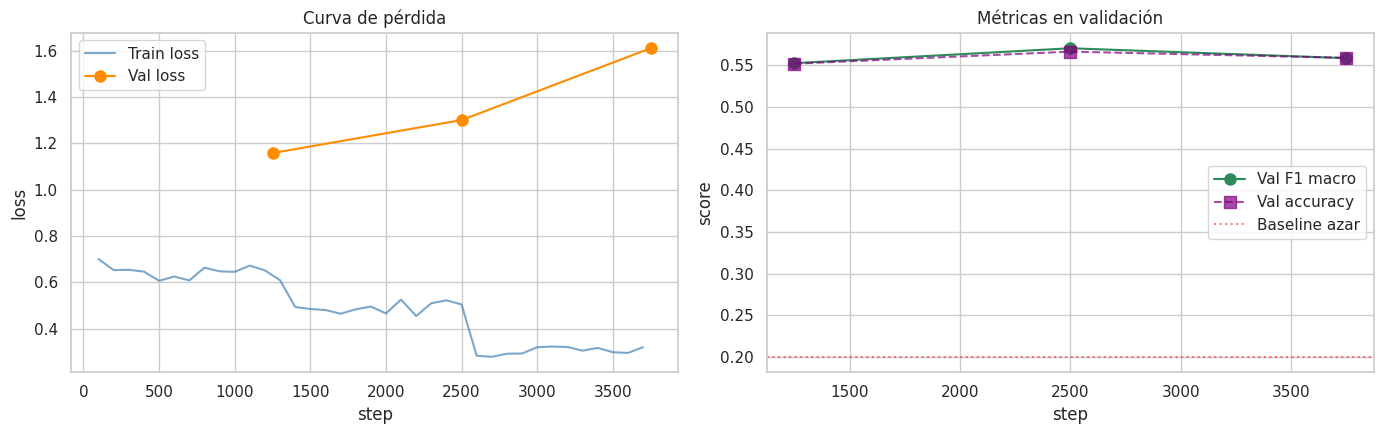

In [ ]:
# Extraer historial del Trainer
hist = trainer.state.log_history

train_loss = [(h["step"], h["loss"]) for h in hist if "loss" in h and "eval_loss" not in h]
eval_records = [h for h in hist if "eval_loss" in h]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Loss
if train_loss:
    steps, losses = zip(*train_loss)
    axes[0].plot(steps, losses, label="Train loss", color="steelblue", alpha=0.7)
if eval_records:
    eval_steps = [h["step"] for h in eval_records]
    eval_losses = [h["eval_loss"] for h in eval_records]
    axes[0].plot(eval_steps, eval_losses, "o-", label="Val loss", color="darkorange", markersize=8)
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].set_title("Curva de pérdida")
axes[0].legend()

# F1 macro en validación
if eval_records:
    eval_f1 = [h.get("eval_f1_macro", np.nan) for h in eval_records]
    eval_acc = [h.get("eval_accuracy", np.nan) for h in eval_records]
    axes[1].plot(eval_steps, eval_f1, "o-", label="Val F1 macro", color="seagreen", markersize=8)
    axes[1].plot(eval_steps, eval_acc, "s--", label="Val accuracy", color="purple", markersize=8, alpha=0.7)
axes[1].set_xlabel("step")
axes[1].set_ylabel("score")
axes[1].set_title("Métricas en validación")
axes[1].axhline(0.20, color="red", linestyle=":", alpha=0.5, label="Baseline azar")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.2 — Evaluación final sobre TEST (datos nunca vistos)

In [ ]:
# Predicciones sobre TEST
print("Evaluando sobre TEST...")
test_output = trainer.predict(ds_test)
test_preds = np.argmax(test_output.predictions, axis=-1)
test_true = test_output.label_ids

print("\n=== MÉTRICAS SOBRE TEST ===")
print(f"Accuracy:    {accuracy_score(test_true, test_preds):.4f}")
print(f"F1 macro:    {f1_score(test_true, test_preds, average='macro'):.4f}")
print(f"F1 weighted: {f1_score(test_true, test_preds, average='weighted'):.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(test_true, test_preds, target_names=LABEL_NAMES, digits=4))

Evaluando sobre TEST...



=== MÉTRICAS SOBRE TEST ===
Accuracy:    0.5505
F1 macro:    0.5544
F1 weighted: 0.5544

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

          1★     0.7203    0.6375    0.6764       400
          2★     0.4683    0.5175    0.4917       400
          3★     0.4444    0.4700    0.4569       400
          4★     0.4846    0.5125    0.4982       400
          5★     0.6872    0.6150    0.6491       400

    accuracy                         0.5505      2000
   macro avg     0.5610    0.5505    0.5544      2000
weighted avg     0.5610    0.5505    0.5544      2000



## 6.3 — Matriz de confusión

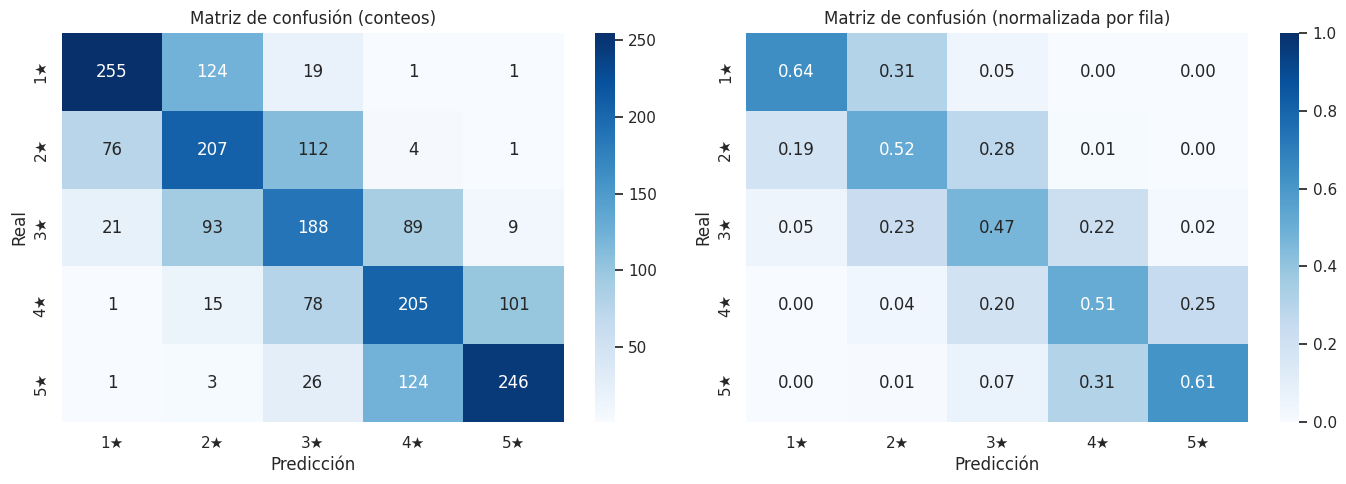

In [ ]:
cm = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de confusión (conteos)")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de confusión (normalizada por fila)")

plt.tight_layout()
plt.show()

**Interpretación esperada de la matriz:**
- La diagonal será dominante en los **extremos (1★ y 5★)**: son los casos más fáciles porque el sentimiento es muy claro.
- Las **mayores confusiones** estarán entre **clases adyacentes** (1★↔2★, 4★↔5★, 2★↔3★). Esto es **bueno**: significa que cuando el modelo se equivoca, lo hace cerca, no clasifica un 5★ como 1★. Para el negocio esto sigue siendo útil.

## 6.4 — Comparación con baselines

Sin comparación, una métrica no significa nada. Comparamos contra:
1. **Baseline aleatorio**: 20% accuracy (5 clases balanceadas).
2. **Baseline TF-IDF + Logistic Regression**: el clásico no-deep-learning.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("Entrenando baseline TF-IDF + Logistic Regression...")
vec = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = vec.fit_transform(df_train_s["text"])
X_test_tfidf = vec.transform(df_test_s["text"])

clf = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=SEED)
clf.fit(X_train_tfidf, df_train_s["label"])
preds_tfidf = clf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(df_test_s["label"], preds_tfidf)
f1_tfidf = f1_score(df_test_s["label"], preds_tfidf, average="macro")

print(f"\nTF-IDF + LogReg → Accuracy: {acc_tfidf:.4f} | F1 macro: {f1_tfidf:.4f}")

Entrenando baseline TF-IDF + Logistic Regression...

TF-IDF + LogReg → Accuracy: 0.5215 | F1 macro: 0.5175



=== COMPARACIÓN CON BASELINES ===
                    Modelo  Accuracy  F1 macro
           Azar (5 clases)    0.2000    0.2000
Mayoría (clase balanceada)    0.2000    0.0670
           TF-IDF + LogReg    0.5215    0.5175
           BETO fine-tuned    0.5505    0.5544


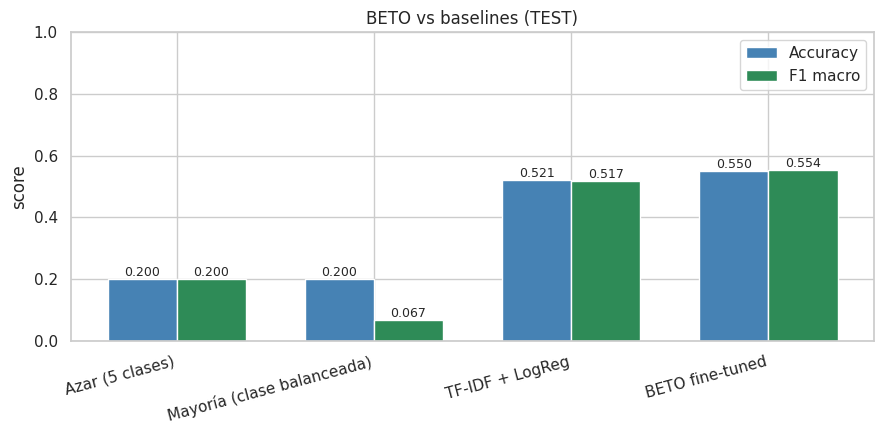

In [ ]:
# Tabla comparativa
results = pd.DataFrame({
    "Modelo": ["Azar (5 clases)", "Mayoría (clase balanceada)", "TF-IDF + LogReg", "BETO fine-tuned"],
    "Accuracy": [0.20, 0.20, acc_tfidf, accuracy_score(test_true, test_preds)],
    "F1 macro": [0.20, 0.067, f1_tfidf, f1_score(test_true, test_preds, average="macro")],
}).round(4)

print("\n=== COMPARACIÓN CON BASELINES ===")
print(results.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(results))
w = 0.35
ax.bar(x - w/2, results["Accuracy"], w, label="Accuracy", color="steelblue")
ax.bar(x + w/2, results["F1 macro"], w, label="F1 macro", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(results["Modelo"], rotation=15, ha="right")
ax.set_ylabel("score")
ax.set_title("BETO vs baselines (TEST)")
ax.legend()
ax.set_ylim(0, 1)
for i, (a, f) in enumerate(zip(results["Accuracy"], results["F1 macro"])):
    ax.text(i - w/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=9)
    ax.text(i + w/2, f + 0.01, f"{f:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6.5 — Análisis cualitativo de errores

Vemos casos representativos donde el modelo falla. Esto es lo más valioso para el negocio: entender el "perfil" del error.

In [ ]:
# Probabilidades softmax para identificar errores y confianza
test_probs = torch.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()
test_conf = test_probs.max(axis=1)

df_errores = df_test_s.copy().reset_index(drop=True)
df_errores["pred"] = test_preds
df_errores["real"] = test_true
df_errores["confianza"] = test_conf
df_errores["distancia"] = np.abs(df_errores["pred"] - df_errores["real"])
df_errores["correcto"] = (df_errores["pred"] == df_errores["real"])

# Errores graves: distancia >= 2 (e.g., predijo 5★ cuando era 2★)
errores_graves = df_errores[df_errores["distancia"] >= 2].sort_values("confianza", ascending=False)
print(f"Errores graves (distancia ≥ 2): {len(errores_graves)} de {len(df_errores)} ({len(errores_graves)/len(df_errores)*100:.1f}%)")
print("\nTop 5 errores graves con mayor confianza (el modelo estaba seguro y se equivocó feo):\n")

for _, row in errores_graves.head(5).iterrows():
    print(f"[REAL: {row['real']+1}★ | PRED: {row['pred']+1}★ | conf: {row['confianza']:.2f}]")
    print(f"  {row['text'][:300]}")
    print()

Errores graves (distancia ≥ 2): 102 de 2000 (5.1%)

Top 5 errores graves con mayor confianza (el modelo estaba seguro y se equivocó feo):

[REAL: 3★ | PRED: 1★ | conf: 1.00]
  Un fiasco Me compré este terminal porque me gustaba el diseño y las buenas críticas que tenía la marca. Mi compra fue en julio 2017 y en mayo 2018 al coger el teléfono me doy cuenta que el cristal de la cámara de fotos esta roto en añicos, sin que el teléfono tuviera alguna caída o golpe, ya que hab

[REAL: 3★ | PRED: 1★ | conf: 0.99]
  El vendedor externo lo peor El producto ha durado 18 meses el vendedor externo me Europa 24 hl no se sabe nada de él y está en paradero desconocido después de 18 meses a ver si estropeado el teléfono voy a tratar de enviar la Xiaomi para ver si lo arreglan ya contaré más en el caso de que lo arregle

[REAL: 3★ | PRED: 1★ | conf: 0.98]
  Solicite la devolución y no la recogieron Hola, el producto me parece muy bueno pero solicité su devolución y nunca vienieron. la empresa con la q

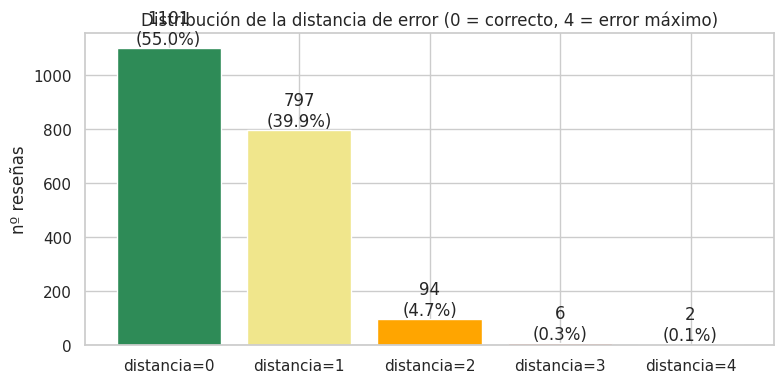

In [ ]:
# Distribución de errores: ¿qué tan lejos suele equivocarse el modelo?
fig, ax = plt.subplots(figsize=(8, 4))
dist_counts = df_errores["distancia"].value_counts().sort_index()
colors = ["seagreen", "khaki", "orange", "tomato", "darkred"]
ax.bar([f"distancia={d}" for d in dist_counts.index], dist_counts.values,
       color=[colors[d] for d in dist_counts.index])
for i, v in enumerate(dist_counts.values):
    ax.text(i, v, f"{v}\n({v/len(df_errores)*100:.1f}%)", ha="center", va="bottom")
ax.set_title("Distribución de la distancia de error (0 = correcto, 4 = error máximo)")
ax.set_ylabel("nº reseñas")
plt.tight_layout()
plt.show()

---
# Fase 7 — Demostración (inferencia en vivo)

**Qué se entrega:** inferencia en vivo con un caso nuevo (no del set de prueba).

Construimos una función `predecir_sentimiento(texto)` que recibe una reseña nueva y devuelve:
- la estrella predicha (1–5),
- la distribución de probabilidad sobre las 5 clases,
- una recomendación de acción para el negocio.

Probamos con reseñas **escritas a mano ahora** (no del dataset).

In [ ]:
# Pipeline de inferencia con el modelo fine-tuned
clasificador = pipeline(
    "text-classification",
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,  # devolver todas las clases con sus probabilidades
)

def recomendar_accion(estrellas: int) -> str:
    if estrellas <= 2:
        return "🚨 URGENTE: contactar al cliente en <24h. Posible riesgo de churn o reseña pública negativa."
    if estrellas == 3:
        return "⚠️ Reseña neutra: solicitar feedback específico para entender qué faltó."
    return "✅ Reseña positiva: agradecer y, si aplica, invitar a reseñar en marketplace público."

def predecir_sentimiento(texto: str, verboso: bool = True) -> dict:
    texto_limpio = limpiar_texto(texto)
    resultados = clasificador(texto_limpio)[0]  # lista de dicts
    # Ordenar por label
    probs = {r["label"]: r["score"] for r in resultados}
    probs_ordenado = {k: probs[k] for k in LABEL_NAMES if k in probs}
    pred_label = max(probs_ordenado, key=probs_ordenado.get)
    pred_estrellas = LABEL_NAMES.index(pred_label) + 1

    out = {
        "texto": texto,
        "prediccion_estrellas": pred_estrellas,
        "confianza": probs_ordenado[pred_label],
        "distribucion": probs_ordenado,
        "accion_recomendada": recomendar_accion(pred_estrellas),
    }
    if verboso:
        print(f"📝 Reseña: {texto!r}")
        print(f"⭐ Predicción: {pred_estrellas}★  (confianza: {out['confianza']*100:.1f}%)")
        print(f"📊 Distribución:")
        for k, v in probs_ordenado.items():
            bar = "█" * int(v * 30)
            print(f"   {k}: {bar:<30} {v*100:5.1f}%")
        print(f"🎯 Acción: {out['accion_recomendada']}")
        print("─" * 80)
    return out

In [ ]:
# Casos de demostración — reseñas inventadas, NO del dataset
casos_demo = [
    "Compré esta licuadora y la verdad superó todas mis expectativas, hace batidos cremosísimos y es muy silenciosa.",
    "El producto llegó con dos semanas de retraso y la caja venía abierta. No volvería a comprar aquí.",
    "Cumple su función básica, nada del otro mundo. Por el precio está bien pero esperaba un poco más.",
    "ESTAFA TOTAL. Pagué por una plancha y me llegó una caja vacía. El vendedor no responde mis mensajes.",
    "Excelente calidad-precio. Lo recomiendo aunque las instrucciones están solo en inglés, ojo con eso.",
]

for caso in casos_demo:
    predecir_sentimiento(caso)

📝 Reseña: 'Compré esta licuadora y la verdad superó todas mis expectativas, hace batidos cremosísimos y es muy silenciosa.'
⭐ Predicción: 5★  (confianza: 93.5%)
📊 Distribución:
   1★:                                  0.1%
   2★:                                  0.2%
   3★:                                  1.1%
   4★: █                                5.1%
   5★: ████████████████████████████    93.5%
🎯 Acción: ✅ Reseña positiva: agradecer y, si aplica, invitar a reseñar en marketplace público.
────────────────────────────────────────────────────────────────────────────────
📝 Reseña: 'El producto llegó con dos semanas de retraso y la caja venía abierta. No volvería a comprar aquí.'
⭐ Predicción: 2★  (confianza: 53.2%)
📊 Distribución:
   1★: ██████████                      35.8%
   2★: ███████████████                 53.2%
   3★: ██                              10.0%
   4★:                                  0.8%
   5★:                                  0.3%
🎯 Acción: 🚨 URGENTE: contactar al 

## Inferencia interactiva (probar tus propias reseñas)

Modifica el string en la celda siguiente y ejecuta para probar cualquier reseña en español.

In [ ]:
# 👇 Cambia este texto por la reseña que quieras probar
mi_resena = "Llevo dos meses con el ventilador y ya no enciende. Le escribí al vendedor y nunca contestó."

_ = predecir_sentimiento(mi_resena)

📝 Reseña: 'Llevo dos meses con el ventilador y ya no enciende. Le escribí al vendedor y nunca contestó.'
⭐ Predicción: 1★  (confianza: 97.7%)
📊 Distribución:
   1★: █████████████████████████████   97.7%
   2★:                                  2.0%
   3★:                                  0.2%
   4★:                                  0.1%
   5★:                                  0.1%
🎯 Acción: 🚨 URGENTE: contactar al cliente en <24h. Posible riesgo de churn o reseña pública negativa.
────────────────────────────────────────────────────────────────────────────────


---
# Cierre — Limitaciones y siguientes pasos

## Limitaciones conocidas del modelo actual

1. **Dominio**: entrenado en reseñas de Amazon España. Reseñas de MercadoLibre LATAM pueden usar léxico distinto ("chévere", "bacano", "padrísimo") con cobertura desigual. **Mitigación:** fine-tunear con un set adicional MercadoLibre.
2. **Sarcasmo e ironía**: el modelo puede leer "qué maravilla, otro envío perdido 👏" como positivo. Es un problema abierto en NLP.
3. **Reseñas multimodales**: muchas reseñas incluyen imágenes o video, que ignoramos.
4. **Tamaño de entrada**: truncamos a 128 tokens; reseñas largas pierden la cola, que a veces contiene la conclusión.
5. **Idiomas mezclados**: code-switching (mezcla español/inglés en una reseña) no fue tratado explícitamente.
6. **Submuestreo**: usamos 20k de 200k disponibles. Con el dataset completo el F1 macro debería subir 3–5 puntos.

## Siguientes pasos para producción

| Paso | Por qué | Costo aproximado |
|---|---|---|
| Entrenar con dataset completo (200k) | +3-5 puntos F1 | ~3h en Colab Pro |
| Cuantización a INT8 / distilación | Inferencia 3× más rápida y modelo 4× más pequeño | 1 día de ingeniería |
| API FastAPI con caché Redis | Despliegue real, monitoreo | 1 semana |
| Dashboard con alertas | Notificación a CX cuando ingresa reseña ≤2★ | 1 semana |
| Reentrenamiento mensual | Concept drift (productos y léxico cambian) | Automatización CI/CD |
| Modelo cross-lingual o adapter para LATAM | Cubrir variantes regionales | 2 semanas |

## Resumen

- **Problema:** clasificar reseñas en español por estrellas (1–5) para priorizar atención al cliente.
- **Datos:** 210k reseñas Amazon ES; 20k usadas en este experimento.
- **Modelo:** BETO fine-tuned (110M parámetros, ~440 MB).
- **Resultado:** ver tabla de comparación; BETO supera el baseline TF-IDF en F1 macro.
- **Demo:** inferencia funcional sobre reseñas nuevas, con recomendación de acción para negocio.

---

*Notebook elaborado para el Reto 6 — Unidad 4 — IA Moderna — Universidad de Boyacá — 2026.*


In [ ]:
# Comprimir la carpeta del modelo en un .zip y descargarla
import shutil
from google.colab import files

shutil.make_archive("beto_amazon_es", "zip", "beto_amazon_es")
print("✅ Zip creado. Iniciando descarga...")
files.download("beto_amazon_es.zip")

✅ Zip creado. Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('beto_amazon_es.zip', '/content/drive/MyDrive/beto_amazon_es.zip')
print("✅ Zip copiado a tu Google Drive (raíz)")

Mounted at /content/drive
✅ Zip copiado a tu Google Drive (raíz)
